# 08_Final_Evaluation_Interpretation

### 1. Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib
import os

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Part A: Reproduce the Untouched Test Set
### 2. Load data

In [5]:
data = pd.read_csv(
    'feature_engineered_data.csv'
)

data['HAS_BUREAU_HISTORY'] = (
    data['BUREAU_LOAN_COUNT'].notna()
).astype(int)

data = data.drop(
    columns=['SK_ID_CURR']
)

X = data.drop(columns='TARGET')
y = data['TARGET']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (50000, 143)
y Shape: (50000,)


### 3. Reproduce the original train/test split

In [6]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Pool:", X_train_full.shape)
print("Untouched Test Set:", X_test.shape)

print(
    "\nTest Default Rate:",
    round(y_test.mean() * 100, 2),
    "%"
)

Training Pool: (40000, 143)
Untouched Test Set: (10000, 143)

Test Default Rate: 8.05 %


### 4. Remove the same high-missingness columns

In [7]:
missing_percentage = (
    X_train_full
    .isnull()
    .mean()
    .mul(100)
)

high_missing_columns = (
    missing_percentage[
        missing_percentage > 60
    ]
    .index
    .tolist()
)

X_test = X_test.drop(
    columns=high_missing_columns
)

print(
    "High-Missingness Columns Removed:",
    len(high_missing_columns)
)

print(
    "Test Shape After Column Removal:",
    X_test.shape
)

High-Missingness Columns Removed: 17
Test Shape After Column Removal: (10000, 126)


# Part B: Load Frozen Models and Threshold
### 5. Load selected XGBoost model

In [8]:
selected_xgboost_model = joblib.load(
    'models/selected_xgboost_model.joblib'
)

In [9]:
# Load the frozen threshold:
final_threshold = joblib.load(
    'models/final_classification_threshold.joblib'
)

print(
    "Frozen Classification Threshold:",
    final_threshold
)

Frozen Classification Threshold: 0.5399999999999998


In [10]:
# Load Logistic Regression:
logistic_model = joblib.load(
    'models/baseline_logistic_regression.joblib'
)

# Part C: Final Test Evaluation
### 6. Generate test probabilities


In [11]:
# XGBoost
xgboost_test_probability = (
    selected_xgboost_model
    .predict_proba(X_test)[:, 1]
)

In [12]:
# Logistic Regression
logistic_test_probability = (
    logistic_model
    .predict_proba(X_test)[:, 1]
)

In [13]:
print(
    "XGBoost Probability Range:",
    xgboost_test_probability.min(),
    xgboost_test_probability.max()
)

print(
    "Logistic Probability Range:",
    logistic_test_probability.min(),
    logistic_test_probability.max()
)

XGBoost Probability Range: 0.06437078 0.89393675
Logistic Probability Range: 3.4124576344854603e-17 0.9669478343171986


### 7. Calculate threshold-independent test metrics

In [14]:
ranking_results = pd.DataFrame({

    'MODEL': [
        'Logistic Regression',
        'Selected XGBoost'
    ],

    'ROC_AUC': [

        roc_auc_score(
            y_test,
            logistic_test_probability
        ),

        roc_auc_score(
            y_test,
            xgboost_test_probability
        )
    ],

    'PR_AUC': [

        average_precision_score(
            y_test,
            logistic_test_probability
        ),

        average_precision_score(
            y_test,
            xgboost_test_probability
        )
    ]
})

ranking_results

,MODEL,ROC_AUC,PR_AUC
0,Logistic Regression,0.745369,0.224043
1,Selected XGBoost,0.752820,0.242427


### 8. Compare validation and test performance

In [15]:
# Create
generalization_comparison = pd.DataFrame({

    'DATASET': [
        'Validation',
        'Test'
    ],

    'ROC_AUC': [
        0.752809,
        roc_auc_score(
            y_test,
            xgboost_test_probability
        )
    ],

    'PR_AUC': [
        0.247865,
        average_precision_score(
            y_test,
            xgboost_test_probability
        )
    ]
})

generalization_comparison


,DATASET,ROC_AUC,PR_AUC
0,Validation,0.752809,0.247865
1,Test,0.752820,0.242427


# Part D: Evaluate the Frozen Threshold
### 9. XGBoost test predictions

In [16]:
xgboost_test_predictions = (
    xgboost_test_probability
    >= final_threshold
).astype(int)

In [17]:
# Calculate metrics
xgb_test_metrics = {

    'PRECISION':
        precision_score(
            y_test,
            xgboost_test_predictions,
            zero_division=0
        ),

    'RECALL':
        recall_score(
            y_test,
            xgboost_test_predictions,
            zero_division=0
        ),

    'F1_SCORE':
        f1_score(
            y_test,
            xgboost_test_predictions,
            zero_division=0
        ),

    'BALANCED_ACCURACY':
        balanced_accuracy_score(
            y_test,
            xgboost_test_predictions
        )
}

pd.Series(xgb_test_metrics)

PRECISION            0.184021
RECALL               0.603727
F1_SCORE             0.282066
BALANCED_ACCURACY    0.684680
dtype: float64

### 10. Classification report

In [18]:
print(
    classification_report(
        y_test,
        xgboost_test_predictions,
        digits=3
    )
)

              precision    recall  f1-score   support

           0      0.957     0.766     0.851      9195
           1      0.184     0.604     0.282       805

    accuracy                          0.753     10000
   macro avg      0.570     0.685     0.566     10000
weighted avg      0.894     0.753     0.805     10000



### 11. Confusion matrix

In [19]:
xgb_test_confusion_matrix = (
    confusion_matrix(
        y_test,
        xgboost_test_predictions
    )
)

xgb_test_confusion_matrix

array([[7040, 2155],
       [ 319,  486]])

In [20]:
# Extract the values:
tn, fp, fn, tp = (
    xgb_test_confusion_matrix.ravel()
)

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 7040
False Positives: 2155
False Negatives: 319
True Positives : 486


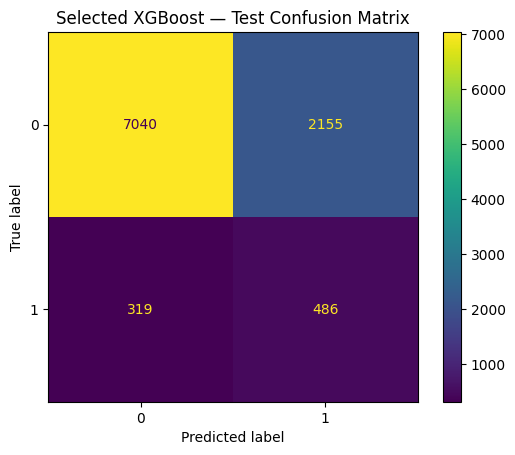

In [21]:
# Plot
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgboost_test_predictions
)

plt.title(
    'Selected XGBoost — Test Confusion Matrix'
)

plt.show()

# Part E: Fair Threshold Comparison with Logistic Regression
### 12. Ranking comparison

In [22]:
ranking_results

,MODEL,ROC_AUC,PR_AUC
0,Logistic Regression,0.745369,0.224043
1,Selected XGBoost,0.752820,0.242427


### 13. Threshold comparison at 0.50

In [23]:
threshold_05_results = []

models = {

    'Logistic Regression':
        logistic_test_probability,

    'Selected XGBoost':
        xgboost_test_probability
}

for model_name, probabilities in models.items():

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    threshold_05_results.append({

        'MODEL':
            model_name,

        'PRECISION':
            precision_score(
                y_test,
                predictions,
                zero_division=0
            ),

        'RECALL':
            recall_score(
                y_test,
                predictions,
                zero_division=0
            ),

        'F1_SCORE':
            f1_score(
                y_test,
                predictions,
                zero_division=0
            ),

        'BALANCED_ACCURACY':
            balanced_accuracy_score(
                y_test,
                predictions
            )
    })

threshold_05_results = pd.DataFrame(
    threshold_05_results
)

threshold_05_results

,MODEL,PRECISION,RECALL,F1_SCORE,BALANCED_ACCURACY
0,Logistic Regression,0.163476,0.689441,0.264286,0.690289
1,Selected XGBoost,0.168748,0.688199,0.271037,0.695704


# Part F: ROC and Precision-Recall Curves
### 14. ROC curves

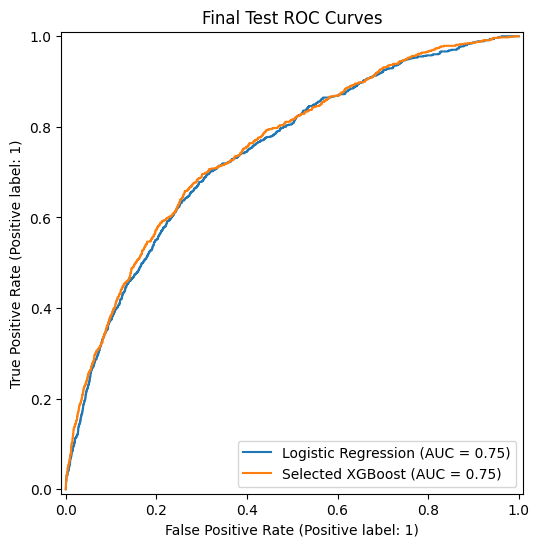

In [24]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

RocCurveDisplay.from_predictions(
    y_test,
    logistic_test_probability,
    name='Logistic Regression',
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    xgboost_test_probability,
    name='Selected XGBoost',
    ax=ax
)

plt.title(
    'Final Test ROC Curves'
)

plt.show()

### 15. Precision-Recall curves

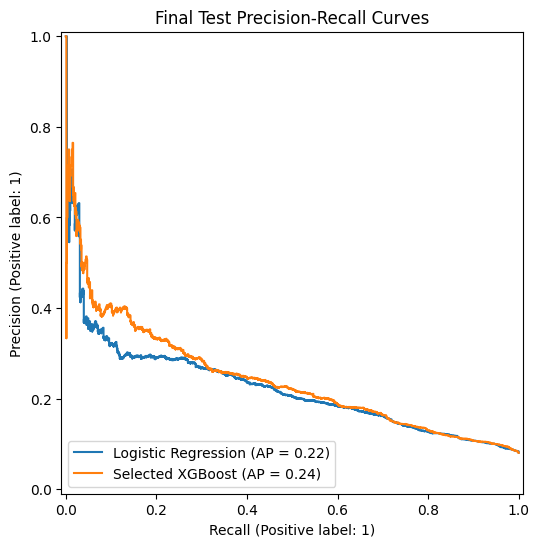

In [25]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    logistic_test_probability,
    name='Logistic Regression',
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    xgboost_test_probability,
    name='Selected XGBoost',
    ax=ax
)

plt.title(
    'Final Test Precision-Recall Curves'
)

plt.show()

# Part G: XGBoost Native Feature Importance


### 16. Extract fitted pipeline components

In [26]:
fitted_preprocessor = (
    selected_xgboost_model
    .named_steps['preprocessor']
)

fitted_xgb_classifier = (
    selected_xgboost_model
    .named_steps['classifier']
)

In [27]:
# Get transformed feature names:
transformed_feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

print(
    "Number of Transformed Features:",
    len(transformed_feature_names)
)

print(
    "Number of XGBoost Importances:",
    len(
        fitted_xgb_classifier
        .feature_importances_
    )
)

Number of Transformed Features: 227
Number of XGBoost Importances: 227


### 17. Create importance table

In [28]:
xgb_importance = pd.DataFrame({

    'FEATURE':
        transformed_feature_names,

    'IMPORTANCE':
        fitted_xgb_classifier
        .feature_importances_

})

In [29]:
# Clean feature prefixes:
xgb_importance['FEATURE'] = (
    xgb_importance['FEATURE']
    .str.replace(
        'num__',
        '',
        regex=False
    )
    .str.replace(
        'cat__',
        '',
        regex=False
    )
)

In [30]:
# Sort:
xgb_importance = (
    xgb_importance
    .sort_values(
        'IMPORTANCE',
        ascending=False
    )
    .reset_index(drop=True)
)

xgb_importance.head(20)

,FEATURE,IMPORTANCE
0,EXT_SOURCE_3,0.042529
1,EXT_SOURCE_2,0.036231
2,NAME_EDUCATION_TYPE_Higher education,0.021664
3,BUREAU_MEAN_DAYS_CREDIT,0.021319
4,EXT_SOURCE_1,0.020187
5,NAME_CONTRACT_TYPE_Cash loans,0.018113
6,FLAG_DOCUMENT_3,0.017579
7,NAME_EDUCATION_TYPE_Secondary / secondary special,0.016472
8,CODE_GENDER_F,0.015608
9,BUREAU_ACTIVE_LOAN_RATIO,0.015346


### 18. Plot top 20 features

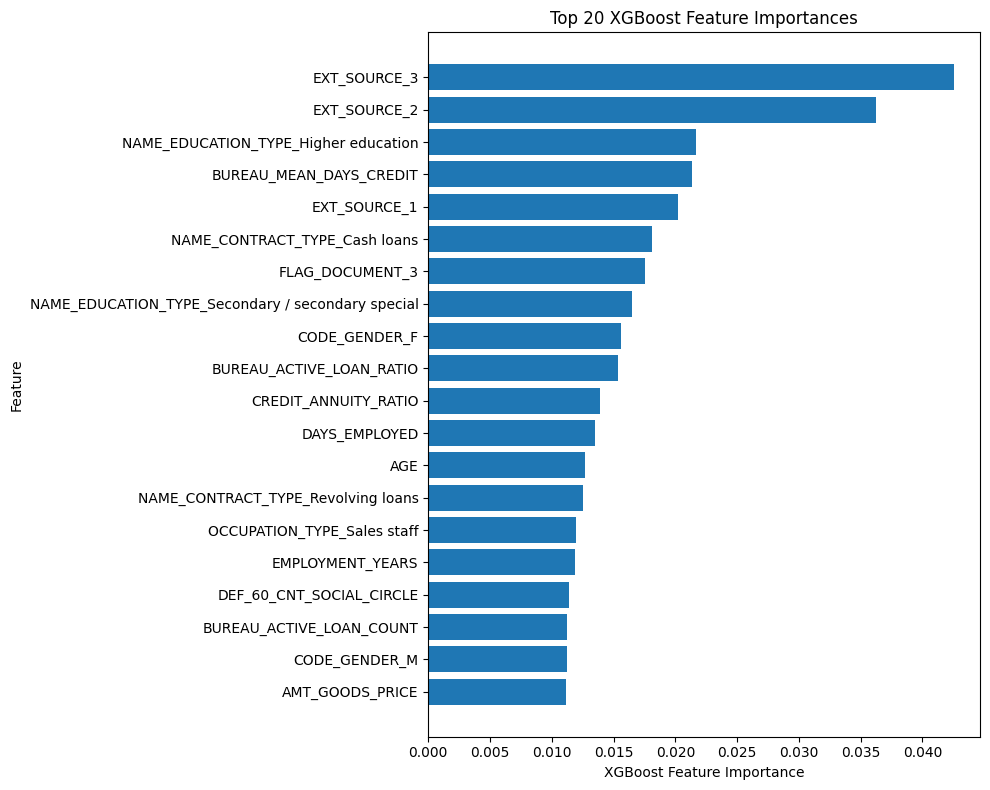

In [31]:
top_xgb_features = (
    xgb_importance.head(20)
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_xgb_features['FEATURE'][::-1],
    top_xgb_features['IMPORTANCE'][::-1]
)

plt.xlabel('XGBoost Feature Importance')

plt.ylabel('Feature')

plt.title(
    'Top 20 XGBoost Feature Importances'
)

plt.tight_layout()

plt.show()

# Part H: Permutation Importance

### 19. Calculate permutation importance


In [32]:
permutation_results = permutation_importance(

    selected_xgboost_model,

    X_test,

    y_test,

    scoring='roc_auc',

    n_repeats=5,

    random_state=42,

    n_jobs=-1
)

### 20. Create permutation-importance table

In [33]:
permutation_importance_df = pd.DataFrame({

    'FEATURE':
        X_test.columns,

    'IMPORTANCE_MEAN':
        permutation_results
        .importances_mean,

    'IMPORTANCE_STD':
        permutation_results
        .importances_std
})

In [34]:
# Sort:
permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        'IMPORTANCE_MEAN',
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_importance_df.head(20)

,FEATURE,IMPORTANCE_MEAN,IMPORTANCE_STD
0,EXT_SOURCE_3,0.048730,0.003419
1,EXT_SOURCE_2,0.046155,0.004678
2,EXT_SOURCE_1,0.014781,0.002764
3,CREDIT_ANNUITY_RATIO,0.007664,0.000946
4,NAME_EDUCATION_TYPE,0.004599,0.000769
5,CODE_GENDER,0.004102,0.001222
6,AMT_GOODS_PRICE,0.003022,0.000568
7,DAYS_ID_PUBLISH,0.001920,0.000251
8,AGE,0.001207,0.000257
9,DEF_60_CNT_SOCIAL_CIRCLE,0.000969,0.000170


### 21. Plot top 20 permutation importances

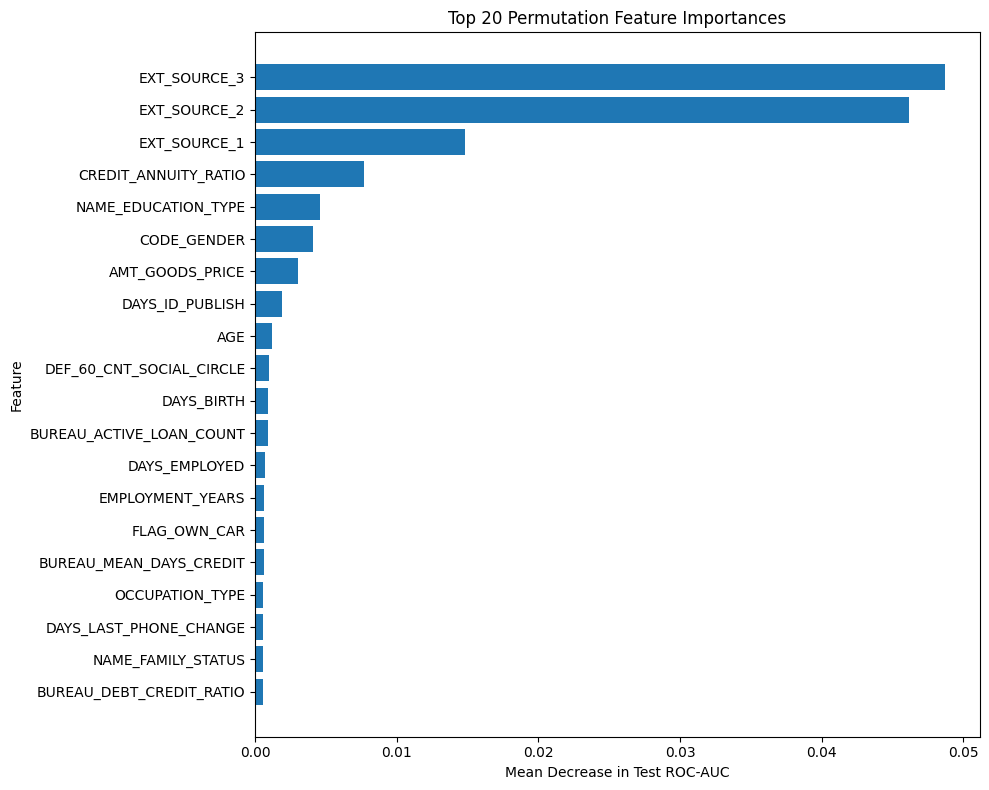

In [35]:
top_permutation_features = (
    permutation_importance_df.head(20)
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_permutation_features[
        'FEATURE'
    ][::-1],

    top_permutation_features[
        'IMPORTANCE_MEAN'
    ][::-1]
)

plt.xlabel(
    'Mean Decrease in Test ROC-AUC'
)

plt.ylabel('Feature')

plt.title(
    'Top 20 Permutation Feature Importances'
)

plt.tight_layout()

plt.show()

# Part I: Save Final Results
### 22. Save final evaluation tables

In [36]:
os.makedirs(
    'reports',
    exist_ok=True
)

ranking_results.to_csv(
    'reports/final_test_ranking_results.csv',
    index=False
)

generalization_comparison.to_csv(
    'reports/xgboost_validation_test_comparison.csv',
    index=False
)

threshold_05_results.to_csv(
    'reports/final_threshold_05_comparison.csv',
    index=False
)

xgb_importance.to_csv(
    'reports/xgboost_feature_importance.csv',
    index=False
)

permutation_importance_df.to_csv(
    'reports/permutation_importance.csv',
    index=False
)

In [37]:
# Save final XGBoost test metrics:
final_xgb_test_results = pd.DataFrame({

    'METRIC': [
        'ROC_AUC',
        'PR_AUC',
        'PRECISION',
        'RECALL',
        'F1_SCORE',
        'BALANCED_ACCURACY',
        'THRESHOLD',
        'TN',
        'FP',
        'FN',
        'TP'
    ],

    'VALUE': [

        roc_auc_score(
            y_test,
            xgboost_test_probability
        ),

        average_precision_score(
            y_test,
            xgboost_test_probability
        ),

        precision_score(
            y_test,
            xgboost_test_predictions,
            zero_division=0
        ),

        recall_score(
            y_test,
            xgboost_test_predictions,
            zero_division=0
        ),

        f1_score(
            y_test,
            xgboost_test_predictions,
            zero_division=0
        ),

        balanced_accuracy_score(
            y_test,
            xgboost_test_predictions
        ),

        final_threshold,

        tn,
        fp,
        fn,
        tp
    ]
})

final_xgb_test_results

,METRIC,VALUE
0,ROC_AUC,0.752820
1,PR_AUC,0.242427
2,PRECISION,0.184021
3,RECALL,0.603727
4,F1_SCORE,0.282066
5,BALANCED_ACCURACY,0.684680
6,THRESHOLD,0.540000
7,TN,7040.000000
8,FP,2155.000000
9,FN,319.000000


In [38]:
final_xgb_test_results.to_csv(
    'reports/final_xgboost_test_results.csv',
    index=False
)

# Final Evaluation and Interpretation Summary

1. The selected XGBoost model and classification threshold were frozen before accessing the untouched test set.

2. Final ranking performance was evaluated using ROC-AUC and PR-AUC because the credit-default target was highly imbalanced.

3. The selected XGBoost model was compared with Logistic Regression using threshold-independent ranking metrics and threshold-dependent classification metrics.

4. The frozen validation-selected threshold was applied directly to the test set without further optimization.

5. The confusion matrix was analyzed to quantify correctly identified defaults, missed defaults, and incorrectly flagged non-default customers.

6. Validation and test performance were compared to assess the model's generalization to unseen customers.

7. XGBoost built-in feature importance was used to inspect features contributing to tree construction.

8. Permutation importance was used as a model-agnostic measure of the decrease in test ROC-AUC caused by disrupting individual raw features.

9. Test-set feature importance was used only for post-hoc model interpretation and not for further model selection, tuning, or feature engineering.

10. The final model results were saved for project documentation and CV preparation.

# Final Project Conclusions

- The selected XGBoost model achieved a test ROC-AUC of approximately 0.753 and PR-AUC of 0.242 on the untouched test set.

- XGBoost outperformed the Logistic Regression benchmark, which achieved a test ROC-AUC of approximately 0.745 and PR-AUC of 0.224.

- Validation and test ROC-AUC values were nearly identical, indicating stable ranking performance across the held-out datasets used in this project.

- At the validation-selected classification threshold of 0.54, the final model achieved approximately 60.4% recall, 18.4% precision, an F1-score of 0.282, and balanced accuracy of 0.685.

- The model identified 486 of 805 defaulting customers while generating 2,155 false-positive risk flags.

- Applicants flagged as high risk had an observed default rate approximately 2.3 times the overall test-set default rate.

- External credit-risk scores (EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3) were the strongest predictors according to both XGBoost built-in importance and permutation importance.

- Financial-ratio, demographic, social-circle, and aggregated bureau-history features also contributed to model performance.

- Hyperparameter tuning produced only a modest improvement over the baseline XGBoost model, suggesting that the initial configuration was already competitive.

- The project demonstrates an end-to-end credit-risk modeling workflow including exploratory analysis, bureau-data aggregation, feature engineering, statistical feature analysis, leakage-aware preprocessing, class-imbalance handling, model comparison, hyperparameter tuning, validation-based threshold selection, untouched test evaluation, and model interpretation.

## Limitations

- The dataset represents a historical lending population, and performance may change under population drift or different lending environments.

- The selected operating threshold represents a simplified recall-constrained decision rule rather than a threshold derived from explicit financial costs of false approvals and false rejections.

- Probability calibration was not evaluated, so predicted probabilities should not be interpreted directly as calibrated default probabilities.

- Some deterministic raw and engineered feature representations were retained together in the tree-model feature set.

- Feature importance describes predictive contribution and should not be interpreted as evidence of causal relationships.

Next, add a small SHAP section at the end of Notebook 8. This is optional for model performance, but useful for explaining directionality and individual predictions.

# Part J: SHAP Interpretation
### 23. Install and import SHAP

In [39]:
import shap

### 24. Extract the fitted XGBoost model and transform a manageable sample

In [40]:
X_shap_sample = X_test.sample(
    n=1000,
    random_state=42
)

X_shap_transformed = (
    fitted_preprocessor
    .transform(X_shap_sample)
)

# SHAP plotting is usually easier with a dense matrix.
if hasattr(X_shap_transformed, 'toarray'):
    X_shap_transformed = (
        X_shap_transformed.toarray()
    )

print(
    "SHAP Sample Shape:",
    X_shap_transformed.shape
)

SHAP Sample Shape: (1000, 227)


### 25. Create the SHAP explainer

In [41]:
explainer = shap.TreeExplainer(
    fitted_xgb_classifier
)

shap_values = explainer(
    X_shap_transformed
)

In [42]:
# Attach feature names:
shap_values.feature_names = (
    transformed_feature_names.tolist()
)

In [43]:
# For cleaner plots, remove the preprocessing prefixes:
clean_feature_names = [
    feature
    .replace('num__', '')
    .replace('cat__', '')

    for feature
    in transformed_feature_names
]

shap_values.feature_names = (
    clean_feature_names
)

### 26. SHAP beeswarm plot

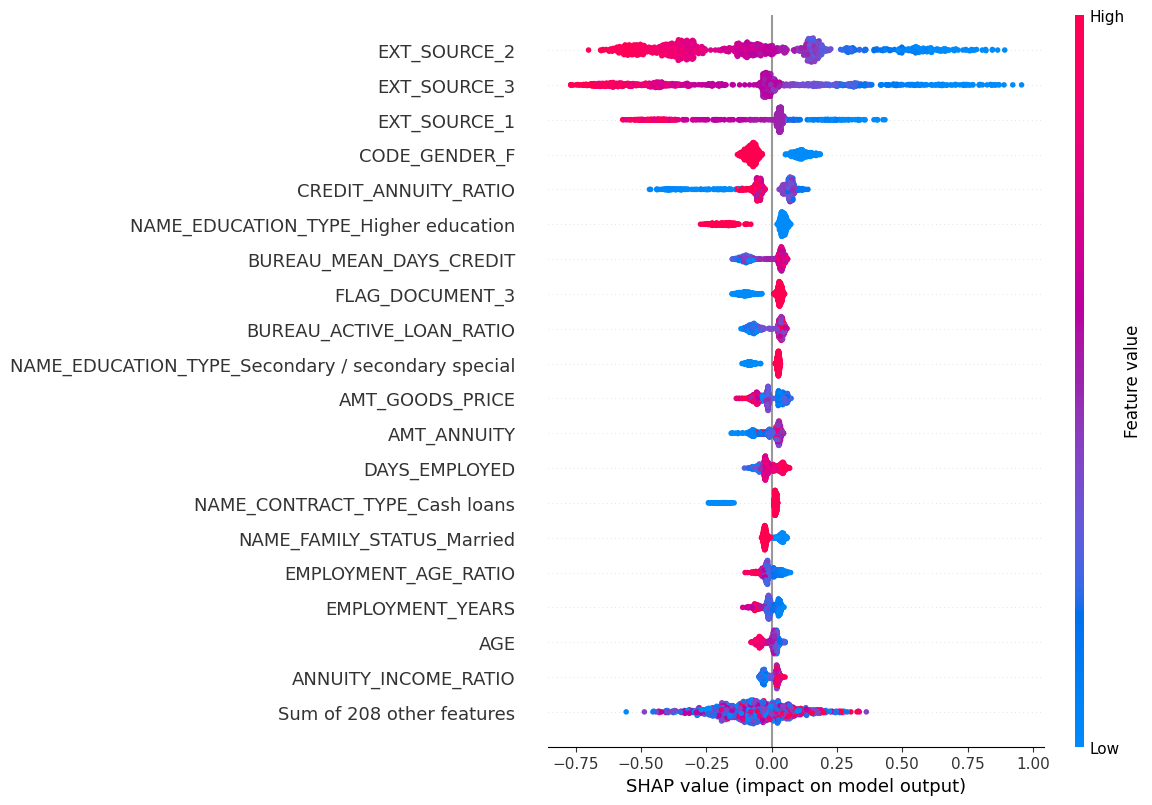

In [44]:
shap.plots.beeswarm(
    shap_values,
    max_display=20
)

### 27. SHAP bar plot

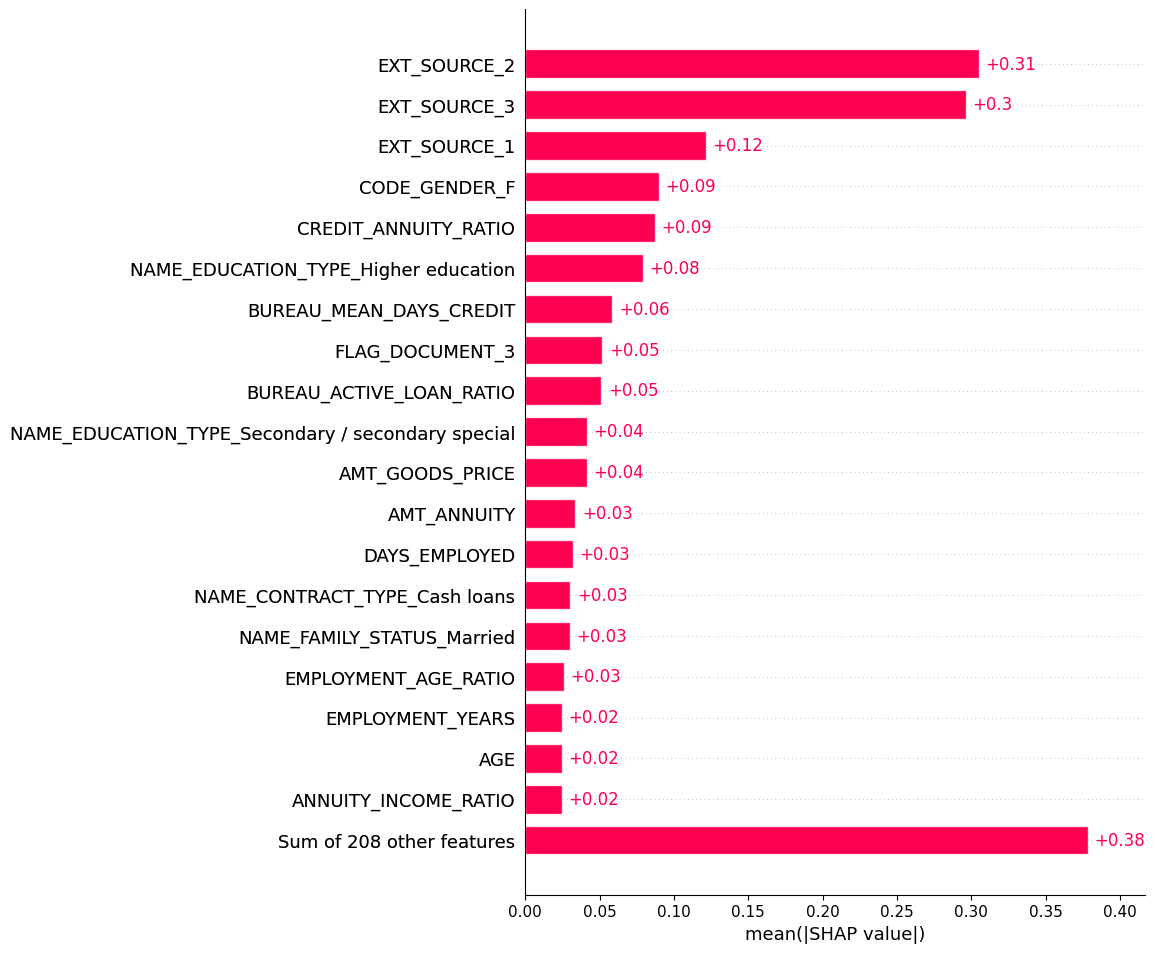

In [45]:
shap.plots.bar(
    shap_values,
    max_display=20
)

# Part K: Local Explanations
### 28. Create a prediction-analysis table

In [47]:
test_prediction_analysis = pd.DataFrame(
    {
        'TRUE_TARGET':
            y_test.values,

        'PREDICTED_PROBABILITY':
            xgboost_test_probability,

        'PREDICTED_CLASS':
            xgboost_test_predictions
    },
    index=X_test.index
)

test_prediction_analysis.head()

,TRUE_TARGET,PREDICTED_PROBABILITY,PREDICTED_CLASS
8511,0,0.534888,0
12530,0,0.355819,0
36699,0,0.269268,0
27479,0,0.317898,0
3162,0,0.406822,0


### 29. Select one true positive

In [48]:
true_positive_candidates = (
    test_prediction_analysis[
        (
            test_prediction_analysis[
                'TRUE_TARGET'
            ] == 1
        )
        &
        (
            test_prediction_analysis[
                'PREDICTED_CLASS'
            ] == 1
        )
    ]
)

tp_index = (
    true_positive_candidates[
        'PREDICTED_PROBABILITY'
    ].idxmax()
)

print(
    test_prediction_analysis.loc[
        tp_index
    ]
)

TRUE_TARGET              1.000000
PREDICTED_PROBABILITY    0.893937
PREDICTED_CLASS          1.000000
Name: 20233, dtype: float64


### 30. Select one false negative

In [49]:
false_negative_candidates = (
    test_prediction_analysis[
        (
            test_prediction_analysis[
                'TRUE_TARGET'
            ] == 1
        )
        &
        (
            test_prediction_analysis[
                'PREDICTED_CLASS'
            ] == 0
        )
    ]
)

fn_index = (
    false_negative_candidates[
        'PREDICTED_PROBABILITY'
    ].idxmax()
)

print(
    test_prediction_analysis.loc[
        fn_index
    ]
)

TRUE_TARGET              1.000000
PREDICTED_PROBABILITY    0.539406
PREDICTED_CLASS          0.000000
Name: 26641, dtype: float64


### 31. Explain the true positive

In [50]:
tp_position = (
    X_test.index.get_loc(tp_index)
)

In [51]:
# Transform
X_tp_transformed = (
    fitted_preprocessor
    .transform(
        X_test.loc[[tp_index]]
    )
)

if hasattr(X_tp_transformed, 'toarray'):
    X_tp_transformed = (
        X_tp_transformed.toarray()
    )

In [53]:
# Calculate SHAP values:
tp_shap_values = explainer(
    X_tp_transformed
)

tp_shap_values.feature_names = (
    clean_feature_names
)

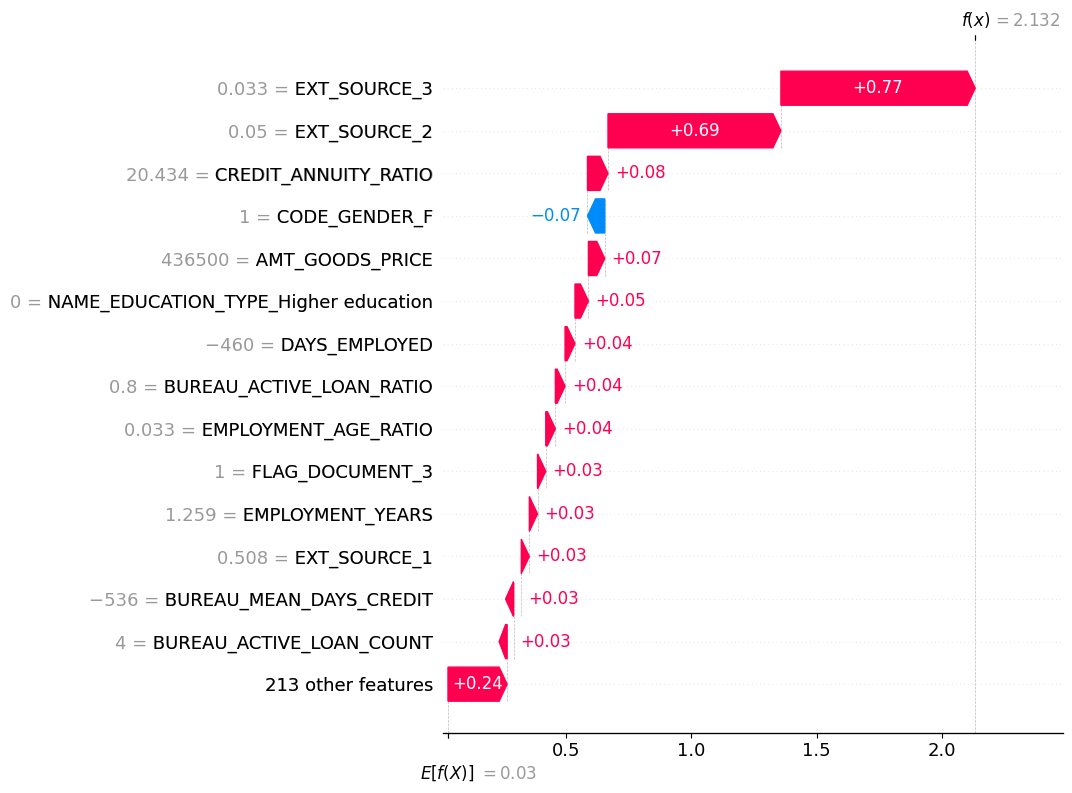

In [54]:
# Plot
shap.plots.waterfall(
    tp_shap_values[0],
    max_display=15
)

### 32. Explain the false negative

In [55]:
X_fn_transformed = (
    fitted_preprocessor
    .transform(
        X_test.loc[[fn_index]]
    )
)

if hasattr(X_fn_transformed, 'toarray'):
    X_fn_transformed = (
        X_fn_transformed.toarray()
    )

In [56]:
fn_shap_values = explainer(
    X_fn_transformed
)

fn_shap_values.feature_names = (
    clean_feature_names
)

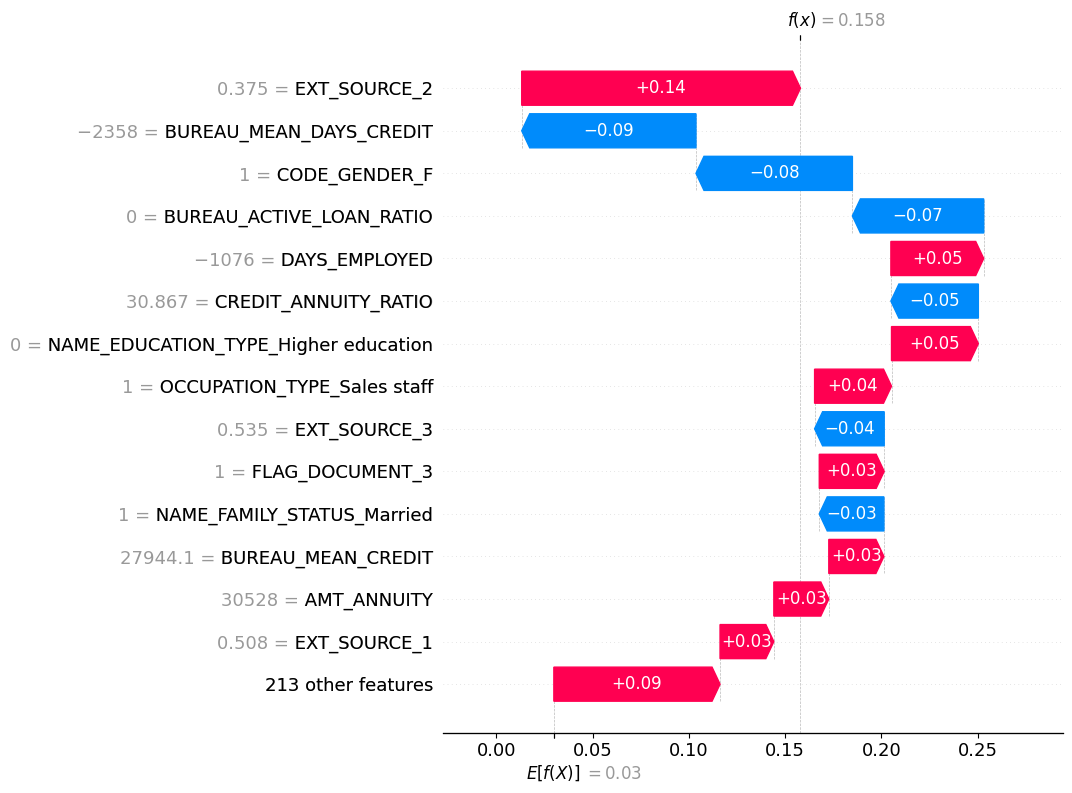

In [57]:
shap.plots.waterfall(
    fn_shap_values[0],
    max_display=15
)

### 33. Save the selected case information

In [58]:
local_explanation_cases = pd.DataFrame({

    'CASE': [
        'True Positive',
        'False Negative'
    ],

    'ROW_INDEX': [
        tp_index,
        fn_index
    ],

    'TRUE_TARGET': [
        test_prediction_analysis.loc[
            tp_index,
            'TRUE_TARGET'
        ],

        test_prediction_analysis.loc[
            fn_index,
            'TRUE_TARGET'
        ]
    ],

    'PREDICTED_PROBABILITY': [
        test_prediction_analysis.loc[
            tp_index,
            'PREDICTED_PROBABILITY'
        ],

        test_prediction_analysis.loc[
            fn_index,
            'PREDICTED_PROBABILITY'
        ]
    ],

    'THRESHOLD': [
        final_threshold,
        final_threshold
    ]
})

local_explanation_cases

,CASE,ROW_INDEX,TRUE_TARGET,PREDICTED_PROBABILITY,THRESHOLD
0,True Positive,20233,1,0.893937,0.54
1,False Negative,26641,1,0.539406,0.54


In [60]:
local_explanation_cases.to_csv(
    'reports/shap_local_explanation_cases.csv',
    index=False
)

# SHAP Interpretation

SHAP analysis was performed on a fixed sample of 1,000 unseen test observations to provide global and local explanations of the selected XGBoost model.

The SHAP beeswarm plot was used to analyze both feature importance and the direction of feature contributions toward higher or lower predicted default risk.

Mean absolute SHAP values were used as an additional global feature-importance measure.

Local waterfall explanations were generated for a correctly identified defaulter and a missed defaulter to examine how individual feature contributions produced different model predictions.

The SHAP analysis was performed only after the model, hyperparameters, and classification threshold had been frozen. SHAP results were used for post-hoc interpretation and not for further model selection or tuning.

## SHAP Analysis — Key Findings

- Global SHAP analysis confirmed that EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3 were the dominant predictors of model output.

- Lower external credit-score values generally pushed predictions toward higher default risk, while higher values reduced predicted risk.

- CREDIT_ANNUITY_RATIO, education category, gender category, and aggregated bureau-history variables also contributed to model predictions.

- The consistency between ANOVA effect sizes, permutation importance, and SHAP importance strengthened the conclusion that external credit-risk scores contained the strongest predictive information.

- For the selected correctly identified defaulter, extremely low EXT_SOURCE_2 and EXT_SOURCE_3 values were the dominant factors pushing the prediction toward default. The model assigned this applicant a default probability of approximately 0.894.

- The selected false-negative applicant received a predicted default probability of approximately 0.539, only 0.0006 below the frozen classification threshold of 0.54.

- SHAP analysis of the false-negative case revealed competing positive and negative feature contributions that nearly cancelled each other, illustrating the effect of threshold selection on borderline applicants.

- SHAP waterfall plots explained the XGBoost raw-margin output in log-odds space rather than predicted probabilities.

- SHAP analysis was performed after the model and threshold had been frozen and was used only for post-hoc interpretation.